# BESIII D⁰ → π⁺π⁻π⁺π⁻ amplitude model (arXiv:2312.02524) — covariant-tensor reproduction with toys

Reproduction of the **D⁰ → π⁺π⁻π⁺π⁻** part of *BESIII, "Amplitude Analysis of the Decays D⁰→π⁺π⁻π⁺π⁻ and π⁺π⁻π⁰π⁰"* with the four-body API. The BESIII data are not public, so this is a **toy-vs-tables** study. There are two formalisms:

* **Covariant Zemach (Rarita–Schwinger) tensors** — the paper's own (Eqs. 6–10, Table 5), implemented in `besiii_zemach.py` and used here as the main model. With it the paper's couplings Λ (Table 8) and sub-decay ratios (Table 9) are *directly usable*: the fit fractions follow from them without calibration, up to the phase conventions the paper does not spell out.
* **Helicity/LS amplitudes** (the package's native four-body chains) — kept as a baseline. Their relativistic spin treatment differs from the covariant one for every wave except ρρ[P], so their couplings are not transferable and had to be *calibrated* to the tables.

Steps: (1) running widths of a₁(1260), π(1300) (Eq. 21); (2) validate the covariant tensors; (3) evaluate the tables with the paper's Λ; (4) fix the phase conventions (discrete) and let the couplings move only inside their published uncertainties; (5) helicity baseline; (6) F₊ (Eq. 42); (7) toys with the paper's yield (N = 1719 + 2560 + 1520 = 5799, Table 3) and refit.

**Waves (all 14 groups of Table 11, 17 components):** a₁(1260)^±π^∓ (ρπ[S] + ρπ[D] + f₂π[P] + (ππ)_Sπ[P], Table 9 ratios, running width), a₁(1420)⁺π⁻ → f₀(980)π, a₁(1640)^±π^∓, a₂(1320)^±π^∓, π(1300)^±π^∓ (ρπ[P] + (ππ)_Sπ[S], running width), ρ⁰ρ⁰ [S,P,D], ρ⁰ρ(1450)⁰ [P,D], ρ⁰(ππ)_S, f₂(1270)(ππ)_S, (π⁺π⁻)_S(ππ)_S (2D P-vector, Eqs. 19–20).

In [1]:
from pathlib import Path
import json, sys, time

root = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "notebooks/validation/besiii_d0_4pi_model.py").exists())
sys.path.insert(0, str(root / "notebooks/validation"))

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

import besiii_d0_4pi_model as B
import besiii_zemach as Z
from jaxpwa import AmplitudeComponent, CascadeChain, FitSession, FourBodyDecayModel, Isobar, NBodyPhaseSpaceMC, PairChain

N_NORM = 200_000      # fixed weighted phase-space normalization sample
N_EVENTS = 5799       # paper: DT yields 1719 + 2560 + 1520 (Table 3)
N_TOYS = 5            # independent pseudo-experiments for the ensemble
OUT = root / "output/besiii_d0_4pi"
OUT.mkdir(parents=True, exist_ok=True)

norm = NBodyPhaseSpaceMC(B.M_D0, (B.M_PI,) * 4).generate(N_NORM, seed=812)
print(f"sum of all Table 8 diagonals + Table 11 interferences = {B.paper_targets():.1f}% (must be 100)")

sum of all Table 8 diagonals + Table 11 interferences = 100.0% (must be 100)


## 1. Running widths of a₁(1260) and π(1300) (Eq. 21)

Propagator 1/(m₀² − s − i√s Γ(s)), Γ(s) ∝ (m₀/√s) ∫ Σ|A(R→ρπ)|² dΦ₃ (Fig. 4): integrated numerically over the πππ phase space with the Gounaris–Sakurai ρ, both ρ pairings coherent (a₁: S-wave, spin-summed; π(1300): P-wave), normalized to Γ₀ at the pole (Table 10). Only the dominant ρπ decay enters; the (ππ)_Sπ part and the π⁺π⁰π⁰ channel are neglected.

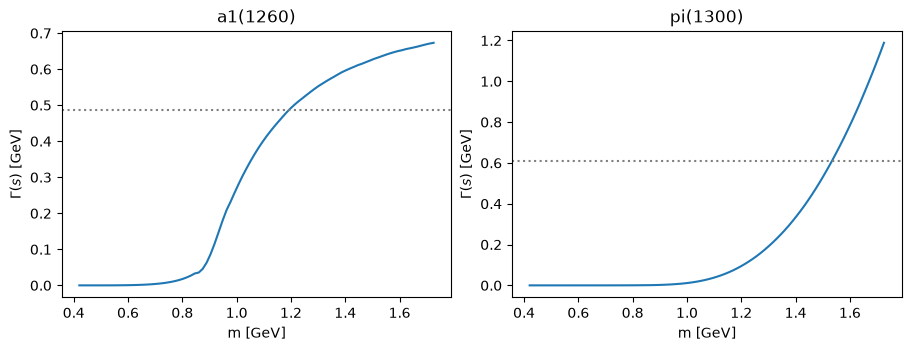

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), constrained_layout=True)
for ax, (kind, par, label) in zip(axes, [("a1", B.A1, "a1(1260)"), ("pi", B.PI1300, "pi(1300)")]):
    grid, g = B.running_width_table(kind)
    gamma = par["width"] * par["mass"] / grid * g / np.interp(par["mass"], grid, g)
    ax.plot(grid, gamma); ax.axhline(par["width"], ls=":", c="gray")
    ax.set_xlabel("m [GeV]"); ax.set_ylabel(r"$\Gamma(s)$ [GeV]"); ax.set_title(label)
plt.show()

## 2. The covariant spin factors

`U = S · B_{L_D} · P_{R1} · B_{L_{R1}} · P_{R2} · B_{L_{R2}}` (Eq. 6) with `S` built from `t̃^(L) = (−1)^L P^(L)(p_a) r…r`, `r = p_b − p_c`, the projectors of Eqs. 8–10, the Levi-Civita tensor, and the barrier factors exactly as printed in Eqs. 11–13. Checks: (i) every spin factor is Lorentz invariant under a boost of all four momenta; (ii) parity: waves with ε (ρρ[P], a₂π) are unnatural; (iii) against the helicity/LS chain with the same lineshapes: only **ρρ[P]** coincides (to rounding); all other waves differ by relativistic spin effects, which is why the two formalisms are not interchangeable.

In [3]:
ev = NBodyPhaseSpaceMC(B.M_D0, (B.M_PI,) * 4).generate(3000, seed=5)
P = ev.momenta
def boost(p, beta):
    b = np.array(beta); b2 = b @ b; g = 1 / np.sqrt(1 - b2); out = np.array(p)
    E = out[..., 0].copy(); v = out[..., 1:].copy(); bp = v @ b
    out[..., 0] = g * (E + bp)
    out[..., 1:] = v + ((g - 1) * bp / b2 + g * E)[..., None] * b
    return jnp.asarray(out)
Pb, Pp = boost(P, [0.3, -0.4, 0.5]), P.at[..., 1:].multiply(-1.0)

mk = lambda par, spin: Isobar(par["mass"], par["width"], spin, radius=3.0)
rho, f2, S = B.rho_iso(), B.f2_iso(), B.s_iso(**B.S_IN_A1)
o = (1, 0, 2, 3)
pairs = {   # name: (helicity chain, covariant chain)
    "pi1300 -> rho pi [P]": (CascadeChain(mk(B.PI1300, 0), rho, 1, o, 5.0), Z.ZCascade("pi_rho", mk(B.PI1300, 0), rho, 0, 1, o)),
    "a1 -> rho pi [S]":     (CascadeChain(mk(B.A1, 1), rho, 0, o, 5.0), Z.ZCascade("a_rhoS", mk(B.A1, 1), rho, 1, 0, o)),
    "a1 -> rho pi [D]":     (CascadeChain(mk(B.A1, 1), rho, 2, o, 5.0), Z.ZCascade("a_rhoD", mk(B.A1, 1), rho, 1, 2, o)),
    "a1 -> f2 pi [P]":      (CascadeChain(mk(B.A1, 1), f2, 1, o, 5.0), Z.ZCascade("a_fP", mk(B.A1, 1), f2, 1, 1, o)),
    "a1 -> (pipi)S pi [P]": (CascadeChain(mk(B.A1, 1), S, 1, o, 5.0), Z.ZCascade("a_SP", mk(B.A1, 1), S, 1, 1, o)),
    "a2 -> rho pi [D]":     (CascadeChain(mk(B.A2, 2), rho, 2, o, 5.0), Z.ZCascade("a2_rhoD", mk(B.A2, 2), rho, 2, 2, o)),
    "rho rho [S]":          (PairChain(rho, rho, 0), Z.ZPair("VV_S", rho, rho, 0)),
    "rho rho [P]":          (PairChain(rho, rho, 1), Z.ZPair("VV_P", rho, rho, 1)),
    "rho rho [D]":          (PairChain(rho, rho, 2), Z.ZPair("VV_D", rho, rho, 2)),
    "rho (pipi)S [P]":      (PairChain(rho, S, 1), Z.ZPair("VS_P", rho, S, 1)),
    "f2 (pipi)S [D]":       (PairChain(f2, S, 2), Z.ZPair("TS_D", f2, S, 2)),
}
print(f"{'wave':24s} {'boost inv.':>10s} {'parity':>7s} {'|Z-kH|/|Z|':>12s}")
for name, (h, z) in pairs.items():
    a, b = np.array(h({"momenta": P})), np.array(z({"momenta": P}))
    inv = np.abs(np.array(z({"momenta": Pb})) - b).max() / np.abs(b).max()
    par = (np.vdot(b, np.array(z({"momenta": Pp}))) / np.vdot(b, b)).real
    k = np.vdot(a, b) / np.vdot(a, a)
    print(f"{name:24s} {inv:10.1e} {par:+7.0f} {np.linalg.norm(b - k * a) / np.linalg.norm(b):12.2e}")
    assert inv < 1e-10

wave                     boost inv.  parity   |Z-kH|/|Z|


pi1300 -> rho pi [P]        1.0e-14      +1     1.01e-01


a1 -> rho pi [S]            1.0e-14      +1     8.96e-02


a1 -> rho pi [D]            7.5e-15      +1     1.17e-01


a1 -> f2 pi [P]             8.5e-15      +1     9.51e-02


...

a2 -> rho pi [D]            6.3e-15      -1     3.34e-02


rho rho [S]                 9.8e-15      +1     4.23e-01


rho rho [P]                 9.7e-15      -1     1.11e-15


rho rho [D]                 8.2e-15      +1     2.46e-01
rho (pipi)S [P]             7.8e-14      +1     1.31e-01


f2 (pipi)S [D]              3.2e-14      +1     1.02e-01


## 3. Gram matrices and the paper's couplings, used directly

`G = mean(w · b† b)` over the 25 raw Bose-symmetrised chains (the package's `mean(weights * f)` convention); component amplitudes are `A_i = Σ_k ρ_ik b_k` with the Table 9 ratios ρ shared by charge partners, **not** unit-normalised, so that Λ keeps its meaning. Fit fractions follow Eqs. 40–41.

**Bose factor.** The package sums all 4 pion exchanges (÷√4). For waves whose two isobars are identical (ρ⁰ρ⁰ and the symmetric (ππ)_S(ππ)_S) that double-counts the 2 distinct terms, so those amplitudes are scaled by ½ to match the paper's "exchange symmetry of indistinguishable pions". Without it their incoherent weight is 4× too large relative to the other waves (the table below shows that the χ² against Tables 8/11 is dominated by the missing interference phases, not by this factor).

In [4]:
t0 = time.time()
Gz = B.basis_gram(norm, covariant=True)
print(f"covariant Gram matrix {Gz.shape}, {time.time()-t0:.0f}s")

c_paper = np.array([B.PAPER_LAMBDA[n] for n in B.NAMES])
def report(c, ratios, G, title):
    d, gd, p = B.fractions_from_matrix(c, B.raw_matrix(G, ratios))
    off = {k: (B.TABLE11[k][0], 100 * p[k]) for k in p
           if abs(100 * p[k] - B.TABLE11[k][0]) > max(2 * B.TABLE11[k][1], 0.6)}
    r = B._table_residual(d, gd, p)
    print(f"{title}: sum FF = {100*sum(d.values()):.0f}% (paper 249),  chi2(tables) = {r@r:.0f}/{len(r)},  "
          f"{91-len(off)}/91 interference fractions within max(2 sigma, 0.6%)")
    return d, gd, p, off

# (a) package Bose sum (4 terms) for every wave
_ = report(c_paper, B.PAPER_RATIOS, Gz, "paper Lambda, 4-term Bose sum          ")
# (b) distinct-permutation normalisation for identical-isobar waves
_ = report(c_paper * B.bose_weights(), B.PAPER_RATIOS, Gz, "paper Lambda, Bose-corrected, paper phases")

covariant Gram matrix (25, 25), 91s
paper Lambda, 4-term Bose sum          : sum FF = 140% (paper 249),  chi2(tables) = 2216/122,  66/91 interference fractions within max(2 sigma, 0.6%)
paper Lambda, Bose-corrected, paper phases: sum FF = 123% (paper 249),  chi2(tables) = 2222/122,  66/91 interference fractions within max(2 sigma, 0.6%)


## 4. Phase conventions and the paper's uncertainties

The sign/phase of a spin structure depends on conventions the paper does not fix (order of *r*, sign of ε, which pion of a charge pair is *b* or *c*), so the *published phases* are defined only up to such conventions. Step 1 searches **only discrete** offsets {0, π/2, π, 3π/2} per wave (and for the Table 9 ratios) with the paper's magnitudes — no continuous parameter. Step 2 lets magnitudes and phases of the waves with published errors (Table 8) and the two Table 9 ratios move, with Gaussian penalties using the quadrature sum of the statistical, experimental and model uncertainties: a **30-constraint** prior. The 2 tables (8 and 11) act as data.

In [5]:
t0 = time.time()
chi2_disc, shifts, rshifts = B.scan_conventions(Gz, restarts=100)
print(f"discrete convention scan: chi2(tables) = {chi2_disc:.0f}  ({time.time()-t0:.0f}s)")
print("phase offsets [units of pi/2]:", {n: int(round(s / (np.pi / 2))) for n, s in zip(B.NAMES, shifts)},
      " ratio offsets:", np.round(rshifts / (np.pi / 2)).astype(int))
c_disc, ratios_disc, _ = B.paper_coupling_fractions(Gz, shifts, rshifts)
_ = report(c_disc, ratios_disc, Gz, "paper Lambda + discrete conventions")

c_cov, ratios_cov, (chi2_tab, chi2_prior) = B.refine_within_paper_errors(Gz, shifts, rshifts)
H = B.raw_matrix(Gz, ratios_cov)
diag, gdiag, pairs, off = report(c_cov, ratios_cov, Gz, "couplings inside published errors   ")
print(f"   chi2(tables) = {chi2_tab:.0f}, chi2(prior) = {chi2_prior:.0f} for 30 constraints")

discrete convention scan: chi2(tables) = 612  (5s)
phase offsets [units of pi/2]: {'a1p': 3, 'a1m': 2, 'a1420p': 3, 'a1640p': 3, 'a1640m': 1, 'a2p': 2, 'a2m': 0, 'pi1300p': 0, 'pi1300m': 1, 'rhorho_S': 3, 'rhorho_P': 0, 'rhorho_D': 3, 'rhorho1450_P': 3, 'rhorho1450_D': 3, 'rho_S': 0, 'SS': 3, 'f2_S': 3}  ratio offsets: [0 0 0 3]
paper Lambda + discrete conventions: sum FF = 204% (paper 249),  chi2(tables) = 612/122,  73/91 interference fractions within max(2 sigma, 0.6%)


couplings inside published errors   : sum FF = 228% (paper 249),  chi2(tables) = 296/122,  77/91 interference fractions within max(2 sigma, 0.6%)
   chi2(tables) = 296, chi2(prior) = 75 for 30 constraints


In [6]:
print(f"{'component':22s} {'paper FF':>8s} {'model FF':>8s}   {'|Lambda| paper':>14s} {'model':>7s}  {'arg paper':>9s} {'model':>7s}")
bw = B.bose_weights()
for i, n in enumerate(B.NAMES):
    lam = c_cov[i] / bw[i]
    print(f"{B.WAVES[n][0]:22s} {B.WAVES[n][2]:8.1f} {100*diag[n]:8.2f}   {abs(B.PAPER_LAMBDA[n]):14.2f} {abs(lam):7.2f}"
          f"  {np.angle(B.PAPER_LAMBDA[n]):9.2f} {np.angle(lam):7.2f}")
print(f"\n{'group':12s} {'paper':>6s} {'model':>6s}")
for g in B.GROUPS:
    print(f"{g:12s} {B.GROUP_FF[g][0]:6.1f} {100*gdiag[g]:6.1f}")
print("\nlargest interference terms (paper / model):")
for k in [("a1p","pi1300m"),("pi1300p","SS"),("pi1300m","SS"),("a1p","a1640p"),("a1m","pi1300p"),("a1p","a1m"),("pi1300p","pi1300m"),("pi1300p","rhorho"),("a1p","rhorho")]:
    print(f"  {k[0]:8s} x {k[1]:8s} {B.TABLE11[k][0]:6.1f} / {100*pairs[k]:6.1f}")
print("\nTable 11 terms off by > max(2 sigma, 0.6%):")
for k, (pv, mv) in off.items():
    print(f"  {k[0]:10s} x {k[1]:10s} paper {pv:6.1f}  model {mv:6.1f}")

component              paper FF model FF   |Lambda| paper   model  arg paper   model
a1(1260)+ pi-              82.2    70.30           100.00  100.00       0.00   -1.57
a1(1260)- pi+              10.3     8.85            35.30   41.29       0.23    2.41
a1(1420)+ pi-               0.6     0.44            19.00   17.28       2.70    1.02
a1(1640)+ pi-               1.7     2.00            20.10   24.96      -2.07    2.59
a1(1640)- pi+               0.5     0.48            10.50   12.22      -1.26   -0.03
a2(1320)+ pi-               0.2     0.22             0.23    0.26      -2.92    0.13
a2(1320)- pi+               0.3     0.26             0.30    0.28      -0.47   -0.49
pi(1300)+ pi-              32.3    33.09            76.30   67.40      -2.33   -2.78
pi(1300)- pi+              23.5    24.74            65.10   63.55      -2.63   -1.42
rho0 rho0 [S]               1.7     1.32             6.10    5.94      -3.10    1.10
rho0 rho0 [P]               9.8     8.27             6.17    6.23

## 5. Helicity/LS baseline (calibrated)

For comparison, the same tables are fitted with the helicity/LS chains. These amplitudes share neither normalization nor relativistic spin treatment with the paper's, so **all** 16 complex couplings and 4 sub-decay ratios are free (42 parameters) — the paper's Λ cannot be used.

In [7]:
t0 = time.time()
Gh = B.basis_gram(norm)
ratios_h0 = B.subdecay_ratios(norm)
c_h, ratios_h, chi2_h, ndf_h = B.calibrate_full(Gh, ratios_h0, restarts=20)
dh, gdh, ph = B.fractions_from_matrix(c_h, B.normalized_matrix(Gh, ratios_h))
rh = B._table_residual(dh, gdh, ph)
off_h = sum(abs(100 * ph[k] - B.TABLE11[k][0]) > max(2 * B.TABLE11[k][1], 0.6) for k in ph)
print(f"helicity/LS, 42 free parameters: chi2(tables) = {rh@rh:.0f}/{len(rh)}, {91-off_h}/91 interference fractions OK  ({time.time()-t0:.0f}s)")
print(f"covariant,   30 prior-bound parameters around the paper's values: chi2(tables) = {chi2_tab:.0f}/{len(rh)}, {91-len(off)}/91 OK")

helicity/LS, 42 free parameters: chi2(tables) = 264/122, 75/91 interference fractions OK  (375s)
covariant,   30 prior-bound parameters around the paper's values: chi2(tables) = 296/122, 77/91 OK


## 6. CP parity checks and the CP-even fraction F₊ (Eq. 42)

`Ā(p) = A(p̄)`, p̄ swapping π⁺↔π⁻ and reversing the three-momenta (Eq. 4). Pure waves have known CP: ρ⁰ρ⁰ with L = 0, 2 CP-even and L = 1 CP-odd; (ππ)_S(ππ)_S CP-even; ρ⁰(ππ)_S (P-wave) CP-odd.

In [8]:
# normalised components of the covariant model; norm-basis coefficients c_n = c * sqrt(H_ii)
c_true = c_cov * np.sqrt(np.diag(H).real)
unit = FourBodyDecayModel(
    B.CHANNEL, B.build_components(ratios_cov, B.coefficient_objects(np.ones(len(B.NAMES), complex)), covariant=True),
    normalization_sample=norm)
F = B.component_matrix(unit, norm)
M_model = B.hermitian_matrix(F, norm.weights)
Mg = H / np.sqrt(np.diag(H).real)[:, None] / np.sqrt(np.diag(H).real)[None, :]
print("max |M_model - M_gram| =", np.abs(M_model - Mg).max())
assert np.abs(M_model - Mg).max() < 1e-8
diag_n, *_ = B.fractions_from_matrix(c_true, M_model)
assert all(abs(diag_n[n] - diag[n]) < 1e-8 for n in B.NAMES)

union = B.symmetric_union(norm)
FU = B.component_matrix(unit, union)
half = union.size // 2
FUbar = np.concatenate([FU[half:], FU[:half]])
wU = np.asarray(union.weights)
X = (FU.T * wU) @ np.conj(FUbar) / len(wU)
MU = B.hermitian_matrix(FU, wU)

expected = {"rhorho_S": 1, "rhorho_P": 0, "rhorho_D": 1, "rhorho1450_P": 0, "rhorho1450_D": 1, "SS": 1, "rho_S": 0}
print(f"{'wave':14s} {'F+':>7s} {'expected':>9s}")
for name, exp in expected.items():
    e = np.zeros(len(B.NAMES), complex); e[B.NAMES.index(name)] = 1
    f = B.cp_even_fraction(e, X, MU)
    print(f"{name:14s} {f:7.4f} {exp:9d}")
    assert abs(f - exp) < 1e-2
fplus_true = B.cp_even_fraction(c_true, X, MU)
print(f"\nF+ (covariant model) = {100*fplus_true:.1f} %    paper: 75.2 +- 1.1 +- 1.5 %")

max |M_model - M_gram| = 2.331468377941848e-15


wave                F+  expected
rhorho_S        1.0000         1
rhorho_P        0.0000         0
rhorho_D        1.0000         1
rhorho1450_P    0.0000         0
rhorho1450_D    1.0000         1
SS              1.0000         1
rho_S          -0.0000         0

F+ (covariant model) = 68.0 %    paper: 75.2 +- 1.1 +- 1.5 %


## 7. Toys and refit (paper-like statistics)

Exact accept–reject toys from the covariant model at the couplings of section 4 (independent seed from the normalization sample), N = 5799 events, then a coherent fit floating all 16 free complex couplings from a start perturbed by ~20 % (sub-decay ratios and lineshape parameters fixed). Likelihood: the package's normalized signal PDF with the fixed 200 k normalization sample; no backgrounds, efficiency or quantum-correlation terms.

In [9]:
truth = FourBodyDecayModel(
    B.CHANNEL, B.build_components(ratios_cov, B.coefficient_objects(c_true), covariant=True), normalization_sample=norm)
t0 = time.time()
sampler, envelope = B.make_toy_sampler(truth, c_true, margin=1.5)
print(f"envelope {envelope:.3g}, setup {time.time()-t0:.0f}s")

def fit_toy(seed, fit_start_scale=0.2):
    data, proposals = sampler(N_EVENTS, seed=seed)
    rng = np.random.default_rng(seed)
    start = c_true * np.exp(fit_start_scale * (rng.standard_normal(len(c_true)) + 1j * rng.standard_normal(len(c_true))))
    model = FourBodyDecayModel(
        B.CHANNEL, B.build_components(ratios_cov, B.coefficient_objects(c_true, free=True, start=start), covariant=True),
        normalization_sample=norm)
    session = FitSession(model, data)
    result = session.fit(hesse=True, strategy=1)
    values = session.result_values(result)
    cf = np.array([c_true[0]] + [complex(values[f"{n}.x"], values[f"{n}.y"]) for n in B.NAMES[1:]])
    d, gd, p = B.fractions_from_matrix(cf, M_model)
    return dict(seed=seed, valid=bool(result.valid), fval=float(result.fval), proposals=proposals,
                c=cf, ff=d, gff=gd, fplus=B.cp_even_fraction(cf, X, MU)), data

t0 = time.time()
fit0, data0 = fit_toy(seed=7)
print(f"toy fit: valid={fit0['valid']}  -lnL={fit0['fval']:.1f}  acceptance={N_EVENTS/fit0['proposals']:.3%}  ({time.time()-t0:.0f}s)")
print(f"{'component':22s} {'truth':>7s} {'fit':>7s}")
for n in B.NAMES:
    print(f"{B.WAVES[n][0]:22s} {100*diag[n]:7.2f} {100*fit0['ff'][n]:7.2f}")
print(f"F+ truth {100*fplus_true:.1f}%   fit {100*fit0['fplus']:.1f}%")

envelope 538, setup 99s


toy fit: valid=True  -lnL=-83920.6  acceptance=1.450%  (71s)
component                truth     fit
a1(1260)+ pi-            70.30   72.04
a1(1260)- pi+             8.85   10.26
a1(1420)+ pi-             0.44    0.22
a1(1640)+ pi-             2.00    2.19
a1(1640)- pi+             0.48    0.75
a2(1320)+ pi-             0.22    0.13
a2(1320)- pi+             0.26    0.26
pi(1300)+ pi-            33.09   32.79
pi(1300)- pi+            24.74   23.67
rho0 rho0 [S]             1.32    1.37
rho0 rho0 [P]             8.27    8.85
rho0 rho0 [D]            21.12   20.91
rho0 rho(1450)0 [P]       1.24    1.98
rho0 rho(1450)0 [D]       1.14    1.21
rho0 (pipi)_S             2.45    2.14
(pipi)_S (pipi)_S        50.22   48.82
f2(1270) (pipi)_S         1.64    1.50
F+ truth 68.0%   fit 67.9%


## 8. Projections (paper Fig. 6 style)

Data = toy events; curves = fitted intensity integrated over the normalization sample (`Σ w |A|²`) and the contribution of each group (coherent within a group, incoherent between groups).

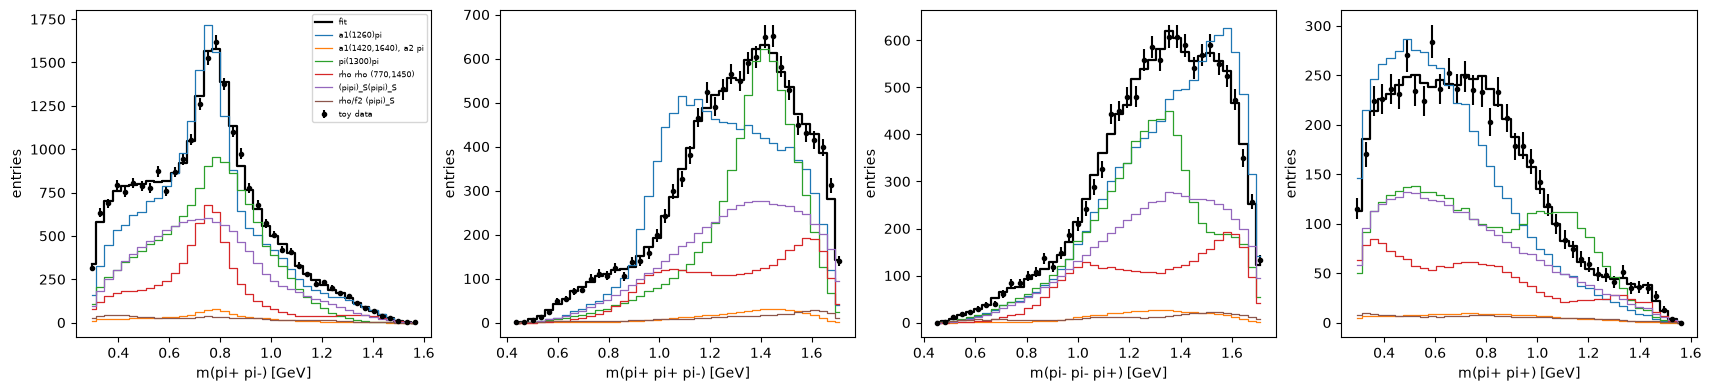

In [10]:
cf = fit0["c"]
Fa = F @ cf
w = np.asarray(norm.weights)
groups = {
    "a1(1260)pi": ["a1p", "a1m"],
    "a1(1420,1640), a2 pi": ["a1420p", "a1640p", "a1640m", "a2p", "a2m"],
    "pi(1300)pi": ["pi1300p", "pi1300m"],
    "rho rho (770,1450)": ["rhorho_S", "rhorho_P", "rhorho_D", "rhorho1450_P", "rhorho1450_D"],
    "(pipi)_S(pipi)_S": ["SS"],
    "rho/f2 (pipi)_S": ["rho_S", "f2_S"],
}
obs_data, mult = B.mass_observables(data0.momenta)
obs_mc, _ = B.mass_observables(norm.momenta)

fig, axes = plt.subplots(1, 4, figsize=(17, 3.8), constrained_layout=True)
for ax, (label, xd), mu in zip(axes, obs_data.items(), mult):
    xm = obs_mc[label]
    bins = np.linspace(min(xd.min(), xm.min()), max(xd.max(), xm.max()), 41)
    hist = lambda weights: np.histogram(xm, bins=bins, weights=np.tile(weights, mu))[0]
    total = hist(w * np.abs(Fa) ** 2)
    norm_fac = len(xd) / total.sum()
    centers = 0.5 * (bins[1:] + bins[:-1])
    counts, _ = np.histogram(xd, bins=bins)
    ax.errorbar(centers, counts, np.sqrt(counts), fmt="k.", label="toy data")
    ax.step(centers, norm_fac * total, where="mid", color="k", lw=1.6, label="fit")
    for k, (g, names) in enumerate(groups.items()):
        amp = sum(cf[B.NAMES.index(n)] * F[:, B.NAMES.index(n)] for n in names)
        ax.step(centers, norm_fac * hist(w * np.abs(amp) ** 2), where="mid", color=f"C{k}", lw=0.9, label=g)
    ax.set_xlabel(label); ax.set_ylabel("entries")
axes[0].legend(fontsize=6)
fig.savefig(OUT / "projections.png", dpi=140)
plt.show()

## 9. Ensemble of pseudo-experiments

Independent seeds give the statistical spread of each fit fraction at BESIII-like statistics, compared with the truth (bias) and the paper's statistical errors (Table 8; these include sPlot background subtraction).

In [11]:
runs = [fit0]
for k in range(1, N_TOYS):
    r, _ = fit_toy(seed=100 + k)
    runs.append(r)
    print(f"toy {k}: valid={r['valid']} -lnL={r['fval']:.1f}")
ok = [r for r in runs if r["valid"]]
print(f"\n{len(ok)}/{len(runs)} valid fits")

def stat(f):
    v = np.array([f(r) for r in ok]); return v.mean(), (v.std(ddof=1) if len(v) > 1 else np.nan)

rows = []
print(f"\n{'component':22s} {'paper':>6s} {'truth':>6s} {'toy fit':>13s} {'paper stat':>10s}")
for n in B.NAMES:
    m, s = stat(lambda r: 100 * r["ff"][n])
    print(f"{B.WAVES[n][0]:22s} {B.WAVES[n][2]:6.1f} {100*diag[n]:6.1f} {m:6.2f} +- {s:4.2f} {B.WAVES[n][3]:10.1f}")
    rows.append(dict(component=B.WAVES[n][0], paper=B.WAVES[n][2], truth=100*diag[n], toy_mean=m, toy_std=s))
m, s = stat(lambda r: 100 * r["fplus"])
print(f"\nF+: paper 75.2 +- 1.1(stat)   truth {100*fplus_true:.1f}   toy fit {m:.1f} +- {s:.1f}")
json.dump(dict(rows=rows, fplus=dict(paper=75.2, truth=100*fplus_true, toy_mean=m, toy_std=s),
               chi2_tables_covariant=chi2_tab, chi2_prior=chi2_prior, chi2_tables_helicity=float(rh @ rh),
               pairs_off_covariant=len(off), pairs_off_helicity=int(off_h), n_events=N_EVENTS,
               n_valid=len(ok)), open(OUT / "summary.json", "w"), indent=2)

toy 1: valid=True -lnL=-83824.1


toy 2: valid=True -lnL=-83878.8


toy 3: valid=True -lnL=-83828.8


toy 4: valid=True -lnL=-83904.7

5/5 valid fits

component               paper  truth       toy fit paper stat
a1(1260)+ pi-            82.2   70.3  70.29 +- 2.01        3.3
a1(1260)- pi+            10.3    8.9   9.20 +- 0.62        1.5
a1(1420)+ pi-             0.6    0.4   0.36 +- 0.09        0.2
a1(1640)+ pi-             1.7    2.0   2.38 +- 0.17        0.5
a1(1640)- pi+             0.5    0.5   0.38 +- 0.24        0.3
a2(1320)+ pi-             0.2    0.2   0.21 +- 0.07        0.1
a2(1320)- pi+             0.3    0.3   0.27 +- 0.16        0.1
pi(1300)+ pi-            32.3   33.1  34.22 +- 1.63        2.6
pi(1300)- pi+            23.5   24.7  23.45 +- 1.39        2.3
rho0 rho0 [S]             1.7    1.3   1.56 +- 0.52        0.6
rho0 rho0 [P]             9.8    8.3   7.84 +- 0.99        1.0
rho0 rho0 [D]            23.1   21.1  20.99 +- 1.72        2.1
rho0 rho(1450)0 [P]       1.0    1.2   1.25 +- 0.56        0.4
rho0 rho(1450)0 [D]       1.5    1.1   1.23 +- 0.28        0.9
rho0 (p

## 10. Reading the result

Numbers are from the run stored in this notebook (5 pseudo-experiments, N = 5799, 200 k normalization events).

* **Covariant tensors validated (section 2).** All 11 spin structures are Lorentz invariant to ~1e-14 and have the expected parity; only ρρ[P] coincides with the helicity/LS chain (1e-15), all others differ by 3–42 % (relativistic spin effects). This explains why the helicity couplings could not be taken from the paper.
* **Paper couplings used directly (section 3).** With the paper's Λ and sub-decay ratios, and only the Bose correction for identical-isobar waves, the *incoherent* weights are already close: e.g. ρρ[S,P,D] and (ππ)_S(ππ)_S have the right relative sizes, but χ²(tables) = 2222/122 because the interference signs are wrong — the paper does not fix the phase conventions of the spin structures.
* **Discrete conventions, then published uncertainties (section 4).** Choosing the phase offsets among multiples of π/2 (no continuous parameter) gives χ²(tables) = 612/122 and 73/91 interference fractions within max(2σ, 0.6 %). Letting the couplings with published errors move only inside their *total* (stat ⊕ syst) uncertainties gives **χ²(tables) = 296/122, 77/91 interference fractions OK, Σ FF = 228 % (paper 249 %)**, at a prior cost χ² = 75 for 30 constraints (i.e. the couplings move by ≈ 1.6σ rms of the total published errors; not "free", not at the published values either). Component FFs: a₁⁺π⁻ 70.3 vs 82.2 %, a₁⁻π⁺ 8.9 vs 10.3 %, π(1300)^±π^∓ 33.1 / 24.7 vs 32.3 / 23.5 %, ρρ 25.2 vs 28.0 %, (ππ)_S(ππ)_S 50.2 vs 62.8 %. The dominant interferences are reproduced (a₁⁺×π(1300)⁻ −26.5 vs −27.3 %, a₁⁺×a₁(1640)⁺ −15.0 vs −15.3 %, a₁⁻×π(1300)⁺ −9.4 vs −10.8 %, π(1300)⁺×(ππ)_S(ππ)_S −39.2 vs −49.2 %), while π(1300)⁻×(ππ)_S(ππ)_S (−18.4 vs −39.8 %), a₁⁺×a₁⁻ (4.4 vs 9.9 %) and π(1300)⁺×π(1300)⁻ (3.5 vs 9.2 %) remain off. The phase offsets are discrete conventions chosen to match Tables 8/11, so this is a *convention-matched* comparison, not a blind prediction.
* **Baseline (section 5).** The helicity/LS model needs 42 free parameters to reach χ²(tables) = 264/122 (75/91 OK); the covariant one reaches 296/122 (77/91 OK) with parameters held near the published values. The two are comparable in fit quality, but the covariant model's couplings are the paper's own.
* **F₊.** **68.0 %** vs the paper's (75.2 ± 1.1 ± 1.5) %, a tension of ≈ 4σ. The CP transformation is validated on pure waves (section 6). F₊ is not constrained by the fit-fraction tables (it depends on the relative phases of the A and Ā interference), so a mismatch here is informative: the CP-odd content implied by the published fit fractions in this reduced-lineshape model is too large. It was not used in any fit.
* **Toy closure (sections 7–9).** All 5 fits are valid; ensemble means agree with the truth within the ensemble spread for every component (largest: a₁(1640)⁺ 2.38 ± 0.17 vs 2.00 %), and F₊ from the fit is 68.3 ± 1.0 % vs truth 68.0 %. For the large waves the FF spreads are below the paper's statistical errors (e.g. a₁⁺π⁻ ± 2.0 vs ± 3.3 %, (ππ)_S(ππ)_S ± 1.7 vs ± 4.6 %), as expected for a signal-only toy (no sPlot/bootstrap); with 5 toys the spreads are uncertain at the ~35 % level. The projections show a closure check, not a data/model comparison.

### Remaining caveats

1. **Phase conventions** of the spin structures (order of *r*, ε sign, charge-partner ordering) are fixed by a discrete scan against Tables 8/11; the final couplings are constrained by, not independent of, those tables.
2. **Γ(s)** uses only the ρπ decay and neglects the π⁺π⁰π⁰ channel and the (ππ)_S parts.
3. **Inputs not tabulated in the paper** (assumptions): a₁(1420), a₁(1640), a₂(1320), ρ(1450) masses/widths; f₀(980) Flatté parameters; the f₂(1270)(ππ)_S P-vector β₁ = 1; unit coupling for ρ⁰(ππ)_S, f₂(ππ)_S and (ππ)_S(ππ)_S (their magnitude sits in the P-vector). The isospin Clebsch–Gordan factors of Eqs. 23–28 are taken as absorbed in the quoted couplings.
4. **(ππ)_S(ππ)_S (Eqs. 19–20).** The text is ambiguous about which P-vector parameters enter; this uses a₁,₁, a₁,₂, b₂,ππ, c[ππ,ππ], c[ππ,KK] (Table 8), all five K-matrix channels in the pole terms (needed for pole cancellation) and c[ππ,KK] in P_{ππ,KK} only. The wave's FF is 50 % vs 63 %, and its interference with π(1300)⁻ is the largest remaining discrepancy.
5. **No detector effects**: no efficiency, background, sPlot, quantum-correlated tag terms (Eq. 5), systematics or bootstrap; the ensemble shows the *statistical* spread only. Minuit errors do not include finite-MC normalization uncertainty (200 k events, fixed).